# Section 1: Notebook Setup & Imports

This section initializes the environment, sets up path resolution, imports libraries for modeling and evaluation, and configures the random seed for reproducibility. We also verify CUDA availability for XGBoost.

In [1]:
import os
import sys
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import torch
import xgboost as xgb
from xgboost import XGBRegressor

def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data'")

PROJECT_ROOT = find_project_root()
print(f"Project root found: {PROJECT_ROOT}")

# Append project root to sys.path
sys_path_root = str(PROJECT_ROOT)
if sys_path_root not in sys.path:
    sys.path.append(sys_path_root)

# Import metrics dashboard from project utilities
try:
    from u_dashboard.dashboard import metrics_dashboard
    print("Imported dashboard from u_dashboard.dashboard")
except ImportError:
    try:
        from Models.Utils.dashboard import metrics_dashboard
        print("Imported dashboard from Models.Utils")
    except ImportError:
        from Utils.dashboard import metrics_dashboard
        print("Imported dashboard from local Utils")

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")

print("Setup complete. Using device:", XGB_DEVICE)

Project root found: C:\Users\pan\Documents\GitHub\MDR-Project
Imported dashboard from u_dashboard.dashboard
Random seed set to 42
XGBoost CUDA support verified and enabled.
Setup complete. Using device: cuda


# Section 2: Data Loading & Preprocessing

This section loads the train, validation, and test splits for the `derived_8.1_pos` dataset. We concatenate the train and validation sets to form the `trainval` split for model training. We parse dates, extract the `year` and `month` features, and compute the temporal recency weights (Drift) using $\beta = 0.2$ as established in the `v25` baseline.

In [2]:
# Define path configurations
TRAIN_PATH = PROJECT_ROOT / "data/splits/derived_8.2/train.csv"
VAL_PATH = PROJECT_ROOT / "data/splits/derived_8.2/val.csv"
TEST_PATH = PROJECT_ROOT / "data/splits/derived_8.2/test.csv"

# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Parse date, extract month and year
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)
    df["year"] = df["date"].dt.year.astype(float)

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

# Compute temporal recency weights (Drift) with beta = 0.2
years_tv = trainval_df["year"]
max_year = years_tv.max()
beta = 0.2
w_trainval = np.exp(beta * (years_tv - max_year))
w_trainval = w_trainval / w_trainval.mean()

print(f"\nTemporal Recency Weighting (Drift) initialized with beta={beta}:")
print(f"  Min weight: {w_trainval.min():.4f}")
print(f"  Max weight: {w_trainval.max():.4f}")


Dataset splits loaded:
  train: (15704, 499)
  val:   (7149, 499)
  test:  (8902, 499)
  trainval (concatenated): (22853, 500)

Temporal Recency Weighting (Drift) initialized with beta=0.2:
  Min weight: 0.5801
  Max weight: 1.5768


# Section 3: Feature Sets Configuration

This section loads the three feature sets to be compared:
- **Model V1**: The 40 features from OVERALL_SELECTED_FEATURES_V1 defined in the derived_8.2 split metadata.
- **Model V2**: The 40 features from OVERALL_SELECTED_FEATURES_V2 defined in the derived_8.2 split metadata.
- **Model V3**: The 47 features from OVERALL_SELECTED_FEATURES_V3 defined in the derived_8.2 split metadata.


In [3]:
# Import Feature Sets from dataset_metadata for derived_8.2
import importlib.util
metadata_path = PROJECT_ROOT / "data/splits/derived_8.2/dataset_metadata.py"
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

FEATURE_SET_V1 = dataset_metadata.OVERALL_SELECTED_FEATURES_V1
FEATURE_SET_V2 = dataset_metadata.OVERALL_SELECTED_FEATURES_V2
FEATURE_SET_V3 = dataset_metadata.OVERALL_SELECTED_FEATURES_V3
FEATURE_SET_V4 = dataset_metadata.OVERALL_SELECTED_FEATURES_V4
FEATURE_SET_V5 = dataset_metadata.OVERALL_SELECTED_FEATURES_V5
TARGET_COL = "soil_moisture_5cm"

print(f"Feature Set V1 count: {len(FEATURE_SET_V1)}")
print(f"Feature Set V2 count: {len(FEATURE_SET_V2)}")
print(f"Feature Set V3 count: {len(FEATURE_SET_V3)}")
print(f"Feature Set V4 count: {len(FEATURE_SET_V4)}")
print(f"Feature Set V5 count: {len(FEATURE_SET_V5)}")


Feature Set V1 count: 40
Feature Set V2 count: 40
Feature Set V3 count: 47
Feature Set V4 count: 50
Feature Set V5 count: 32


# Section 4: Evaluation Utilities & Parameters

We define the metrics calculation utility and target variables. We also set up the hyperparameters for the XGBoost model configurations matching `MDR-v25.ipynb`:
- `XGB_PARAMS_NO_W`: The non-weighted baseline using `reg:absoluteerror`.
- `XGB_PARAMS_W`: The weighted baseline using `reg:pseudohubererror`.

In [4]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson
    }

def print_metrics(metrics, title):
    print(f"\n===== {title} =====")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.5f}")

XGB_PARAMS_NO_W = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

XGB_PARAMS_W = dict(
    objective="reg:pseudohubererror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

# Section 5: Model V1 Evaluation (40 Features from OVERALL_SELECTED_FEATURES_V1)

We train and evaluate two global XGBoost models using Feature Set V1 (40 features):
1. **Model V1 (No Weights)**: Trained with `reg:absoluteerror` objective and no sample weighting.
2. **Model V1 (Weighted)**: Trained with `reg:pseudohubererror` objective and temporal recency weights ($\beta=0.2$).


In [5]:
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
y_test = np.asarray(test_df[TARGET_COL]).ravel()

# Define model weight paths
out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-eval-1.2"
out_dir.mkdir(parents=True, exist_ok=True)

model_v1_no_w_path = out_dir / "xgb_v1_no_w.json"
model_v1_w_path = out_dir / "xgb_v1_w.json"

# 1. Non-weighted model
xgb_v1_no_w = XGBRegressor()
if model_v1_no_w_path.exists():
    print("Loading Model V1 (No Weights) from saved weights...")
    xgb_v1_no_w.load_model(str(model_v1_no_w_path))
else:
    print("Training Model V1 (40 features, No Weights)...")
    xgb_v1_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
    xgb_v1_no_w.fit(trainval_df[FEATURE_SET_V1], y_trainval, verbose=0)
    xgb_v1_no_w.save_model(str(model_v1_no_w_path))

pred_v1_no_w = np.asarray(xgb_v1_no_w.predict(test_df[FEATURE_SET_V1])).ravel()
metrics_v1_no_w = compute_metrics(y_test, pred_v1_no_w)
print_metrics(metrics_v1_no_w, "MODEL V1 (40 FEAT, NO WEIGHTS) METRICS")

# 2. Weighted model
xgb_v1_w = XGBRegressor()
if model_v1_w_path.exists():
    print("Loading Model V1 (Weighted) from saved weights...")
    xgb_v1_w.load_model(str(model_v1_w_path))
else:
    print("Training Model V1 (40 features, Weighted)...")
    xgb_v1_w = XGBRegressor(**XGB_PARAMS_W)
    xgb_v1_w.fit(trainval_df[FEATURE_SET_V1], y_trainval, sample_weight=w_trainval, verbose=0)
    xgb_v1_w.save_model(str(model_v1_w_path))

pred_v1_w = np.asarray(xgb_v1_w.predict(test_df[FEATURE_SET_V1])).ravel()
metrics_v1_w = compute_metrics(y_test, pred_v1_w)
print_metrics(metrics_v1_w, "MODEL V1 (40 FEAT, WEIGHTED) METRICS")


Loading Model V1 (No Weights) from saved weights...



===== MODEL V1 (40 FEAT, NO WEIGHTS) METRICS =====
R2        : 0.60910
RMSE      : 0.06584
ubRMSE    : 0.06447
Bias      : -0.01333
MAE       : 0.04836
Med|Err|  : 0.03581
Pearson   : 0.79835
Loading Model V1 (Weighted) from saved weights...



===== MODEL V1 (40 FEAT, WEIGHTED) METRICS =====
R2        : 0.62631
RMSE      : 0.06437
ubRMSE    : 0.06303
Bias      : -0.01306
MAE       : 0.04788
Med|Err|  : 0.03691
Pearson   : 0.80842


# Section 6: Model V2 Evaluation (40 Features from OVERALL_SELECTED_FEATURES_V2)

We train and evaluate two global XGBoost models using Feature Set V2 (40 features):
1. **Model V2 (No Weights)**: Trained with `reg:absoluteerror` objective and no sample weighting.
2. **Model V2 (Weighted)**: Trained with `reg:pseudohubererror` objective and temporal recency weights ($\beta=0.2$).


In [6]:
model_v2_no_w_path = out_dir / "xgb_v2_no_w.json"
model_v2_w_path = out_dir / "xgb_v2_w.json"

# 1. Non-weighted model
xgb_v2_no_w = XGBRegressor()
if model_v2_no_w_path.exists():
    print("Loading Model V2 (No Weights) from saved weights...")
    xgb_v2_no_w.load_model(str(model_v2_no_w_path))
else:
    print("Training Model V2 (40 features, No Weights)...")
    xgb_v2_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
    xgb_v2_no_w.fit(trainval_df[FEATURE_SET_V2], y_trainval, verbose=0)
    xgb_v2_no_w.save_model(str(model_v2_no_w_path))

pred_v2_no_w = np.asarray(xgb_v2_no_w.predict(test_df[FEATURE_SET_V2])).ravel()
metrics_v2_no_w = compute_metrics(y_test, pred_v2_no_w)
print_metrics(metrics_v2_no_w, "MODEL V2 (40 FEAT, NO WEIGHTS) METRICS")

# 2. Weighted model
xgb_v2_w = XGBRegressor()
if model_v2_w_path.exists():
    print("Loading Model V2 (Weighted) from saved weights...")
    xgb_v2_w.load_model(str(model_v2_w_path))
else:
    print("Training Model V2 (40 features, Weighted)...")
    xgb_v2_w = XGBRegressor(**XGB_PARAMS_W)
    xgb_v2_w.fit(trainval_df[FEATURE_SET_V2], y_trainval, sample_weight=w_trainval, verbose=0)
    xgb_v2_w.save_model(str(model_v2_w_path))

pred_v2_w = np.asarray(xgb_v2_w.predict(test_df[FEATURE_SET_V2])).ravel()
metrics_v2_w = compute_metrics(y_test, pred_v2_w)
print_metrics(metrics_v2_w, "MODEL V2 (40 FEAT, WEIGHTED) METRICS")


Loading Model V2 (No Weights) from saved weights...



===== MODEL V2 (40 FEAT, NO WEIGHTS) METRICS =====
R2        : 0.63471
RMSE      : 0.06364
ubRMSE    : 0.06004
Bias      : -0.02111
MAE       : 0.04839
Med|Err|  : 0.03746
Pearson   : 0.82517
Loading Model V2 (Weighted) from saved weights...



===== MODEL V2 (40 FEAT, WEIGHTED) METRICS =====
R2        : 0.64263
RMSE      : 0.06295
ubRMSE    : 0.05952
Bias      : -0.02051
MAE       : 0.04736
Med|Err|  : 0.03586
Pearson   : 0.83024


# Section 6b: Model V3 Evaluation (47 Features from OVERALL_SELECTED_FEATURES_V3)

We train and evaluate two global XGBoost models using Feature Set V3 (47 features):
1. **Model V3 (No Weights)**: Trained with eg:absoluteerror objective and no sample weighting.
2. **Model V3 (Weighted)**: Trained with eg:pseudohubererror objective and temporal recency weights ($\beta=0.2$).

In [7]:
model_v3_no_w_path = out_dir / "xgb_v3_no_w.json"
model_v3_w_path = out_dir / "xgb_v3_w.json"

# 1. Non-weighted model
xgb_v3_no_w = XGBRegressor()
if model_v3_no_w_path.exists():
    print("Loading Model V3 (No Weights) from saved weights...")
    xgb_v3_no_w.load_model(str(model_v3_no_w_path))
else:
    print("Training Model V3 (47 features, No Weights)...")
    xgb_v3_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
    xgb_v3_no_w.fit(trainval_df[FEATURE_SET_V3], y_trainval, verbose=0)
    xgb_v3_no_w.save_model(str(model_v3_no_w_path))

pred_v3_no_w = np.asarray(xgb_v3_no_w.predict(test_df[FEATURE_SET_V3])).ravel()
metrics_v3_no_w = compute_metrics(y_test, pred_v3_no_w)
print_metrics(metrics_v3_no_w, "MODEL V3 (47 FEAT, NO WEIGHTS) METRICS")

# 2. Weighted model
xgb_v3_w = XGBRegressor()
if model_v3_w_path.exists():
    print("Loading Model V3 (Weighted) from saved weights...")
    xgb_v3_w.load_model(str(model_v3_w_path))
else:
    print("Training Model V3 (47 features, Weighted)...")
    xgb_v3_w = XGBRegressor(**XGB_PARAMS_W)
    xgb_v3_w.fit(trainval_df[FEATURE_SET_V3], y_trainval, sample_weight=w_trainval, verbose=0)
    xgb_v3_w.save_model(str(model_v3_w_path))

pred_v3_w = np.asarray(xgb_v3_w.predict(test_df[FEATURE_SET_V3])).ravel()
metrics_v3_w = compute_metrics(y_test, pred_v3_w)
print_metrics(metrics_v3_w, "MODEL V3 (47 FEAT, WEIGHTED) METRICS")


Loading Model V3 (No Weights) from saved weights...



===== MODEL V3 (47 FEAT, NO WEIGHTS) METRICS =====
R2        : 0.64735
RMSE      : 0.06253
ubRMSE    : 0.05886
Bias      : -0.02113
MAE       : 0.04748
Med|Err|  : 0.03636
Pearson   : 0.83224
Loading Model V3 (Weighted) from saved weights...



===== MODEL V3 (47 FEAT, WEIGHTED) METRICS =====
R2        : 0.63738
RMSE      : 0.06341
ubRMSE    : 0.05976
Bias      : -0.02119
MAE       : 0.04757
Med|Err|  : 0.03615
Pearson   : 0.82961


# Section 6c: Model V4 Evaluation (50 Features from OVERALL_SELECTED_FEATURES_V4)

We train and evaluate two global XGBoost models using Feature Set V4 (50 features):
1. **Model V4 (No Weights)**: Trained with eg:absoluteerror objective and no sample weighting.
2. **Model V4 (Weighted)**: Trained with eg:pseudohubererror objective and temporal recency weights ($\beta=0.2$).

In [8]:
model_v4_no_w_path = out_dir / "xgb_v4_no_w.json"
model_v4_w_path = out_dir / "xgb_v4_w.json"

# 1. Non-weighted model
xgb_v4_no_w = XGBRegressor()
if model_v4_no_w_path.exists():
    print("Loading Model V4 (No Weights) from saved weights...")
    xgb_v4_no_w.load_model(str(model_v4_no_w_path))
else:
    print("Training Model V4 (50 features, No Weights)...")
    xgb_v4_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
    xgb_v4_no_w.fit(trainval_df[FEATURE_SET_V4], y_trainval, verbose=0)
    xgb_v4_no_w.save_model(str(model_v4_no_w_path))

pred_v4_no_w = np.asarray(xgb_v4_no_w.predict(test_df[FEATURE_SET_V4])).ravel()
metrics_v4_no_w = compute_metrics(y_test, pred_v4_no_w)
print_metrics(metrics_v4_no_w, "MODEL V4 (50 FEAT, NO WEIGHTS) METRICS")

# 2. Weighted model
xgb_v4_w = XGBRegressor()
if model_v4_w_path.exists():
    print("Loading Model V4 (Weighted) from saved weights...")
    xgb_v4_w.load_model(str(model_v4_w_path))
else:
    print("Training Model V4 (50 features, Weighted)...")
    xgb_v4_w = XGBRegressor(**XGB_PARAMS_W)
    xgb_v4_w.fit(trainval_df[FEATURE_SET_V4], y_trainval, sample_weight=w_trainval, verbose=0)
    xgb_v4_w.save_model(str(model_v4_w_path))

pred_v4_w = np.asarray(xgb_v4_w.predict(test_df[FEATURE_SET_V4])).ravel()
metrics_v4_w = compute_metrics(y_test, pred_v4_w)
print_metrics(metrics_v4_w, "MODEL V4 (50 FEAT, WEIGHTED) METRICS")

Loading Model V4 (No Weights) from saved weights...



===== MODEL V4 (50 FEAT, NO WEIGHTS) METRICS =====
R2        : 0.60883
RMSE      : 0.06586
ubRMSE    : 0.06423
Bias      : -0.01454
MAE       : 0.04873
Med|Err|  : 0.03755
Pearson   : 0.79593
Loading Model V4 (Weighted) from saved weights...



===== MODEL V4 (50 FEAT, WEIGHTED) METRICS =====
R2        : 0.60365
RMSE      : 0.06629
ubRMSE    : 0.06484
Bias      : -0.01382
MAE       : 0.04891
Med|Err|  : 0.03717
Pearson   : 0.79332


# Section 6d: Model V5 Evaluation (Selected Features from OVERALL_SELECTED_FEATURES_V5)

We train and evaluate two global XGBoost models using Feature Set V5:
1. **Model V5 (No Weights)**: Trained with eg:absoluteerror objective and no sample weighting.
2. **Model V5 (Weighted)**: Trained with eg:pseudohubererror objective and temporal recency weights ($\beta=0.2$).

In [9]:
model_v5_no_w_path = out_dir / "xgb_v5_no_w.json"
model_v5_w_path = out_dir / "xgb_v5_w.json"

# 1. Non-weighted model
xgb_v5_no_w = XGBRegressor()
if model_v5_no_w_path.exists():
    print("Loading Model V5 (No Weights) from saved weights...")
    xgb_v5_no_w.load_model(str(model_v5_no_w_path))
else:
    print("Training Model V5 (No Weights)...")
    xgb_v5_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
    xgb_v5_no_w.fit(trainval_df[FEATURE_SET_V5], y_trainval, verbose=0)
    xgb_v5_no_w.save_model(str(model_v5_no_w_path))

pred_v5_no_w = np.asarray(xgb_v5_no_w.predict(test_df[FEATURE_SET_V5])).ravel()
metrics_v5_no_w = compute_metrics(y_test, pred_v5_no_w)
print_metrics(metrics_v5_no_w, "MODEL V5 (NO WEIGHTS) METRICS")

# 2. Weighted model
xgb_v5_w = XGBRegressor()
if model_v5_w_path.exists():
    print("Loading Model V5 (Weighted) from saved weights...")
    xgb_v5_w.load_model(str(model_v5_w_path))
else:
    print("Training Model V5 (Weighted)...")
    xgb_v5_w = XGBRegressor(**XGB_PARAMS_W)
    xgb_v5_w.fit(trainval_df[FEATURE_SET_V5], y_trainval, sample_weight=w_trainval, verbose=0)
    xgb_v5_w.save_model(str(model_v5_w_path))

pred_v5_w = np.asarray(xgb_v5_w.predict(test_df[FEATURE_SET_V5])).ravel()
metrics_v5_w = compute_metrics(y_test, pred_v5_w)
print_metrics(metrics_v5_w, "MODEL V5 (WEIGHTED) METRICS")

Loading Model V5 (No Weights) from saved weights...



===== MODEL V5 (NO WEIGHTS) METRICS =====
R2        : 0.59568
RMSE      : 0.06696
ubRMSE    : 0.06565
Bias      : -0.01316
MAE       : 0.04995
Med|Err|  : 0.03856
Pearson   : 0.78639
Loading Model V5 (Weighted) from saved weights...



===== MODEL V5 (WEIGHTED) METRICS =====
R2        : 0.59476
RMSE      : 0.06703
ubRMSE    : 0.06570
Bias      : -0.01331
MAE       : 0.04990
Med|Err|  : 0.03857
Pearson   : 0.78705


# Section 7: Comparative Summary & Visualization

We print the summary metrics table comparing the six configurations and generate residual scatter plots.



===== COMPARATIVE PERFORMANCE SUMMARY =====
                     Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
Model V1 (40 Features, No Weights) 0.6091 0.0658 0.0645 -0.0133 0.0484   0.0358  0.7984
  Model V1 (40 Features, Weighted) 0.6263 0.0644 0.0630 -0.0131 0.0479   0.0369  0.8084
Model V2 (40 Features, No Weights) 0.6347 0.0636 0.0600 -0.0211 0.0484   0.0375  0.8252
  Model V2 (40 Features, Weighted) 0.6426 0.0629 0.0595 -0.0205 0.0474   0.0359  0.8302
Model V3 (47 Features, No Weights) 0.6474 0.0625 0.0589 -0.0211 0.0475   0.0364  0.8322
  Model V3 (47 Features, Weighted) 0.6374 0.0634 0.0598 -0.0212 0.0476   0.0361  0.8296
Model V4 (50 Features, No Weights) 0.6088 0.0659 0.0642 -0.0145 0.0487   0.0376  0.7959
  Model V4 (50 Features, Weighted) 0.6036 0.0663 0.0648 -0.0138 0.0489   0.0372  0.7933
Model V5 (32 Features, No Weights) 0.5957 0.0670 0.0657 -0.0132 0.0500   0.0386  0.7864
  Model V5 (32 Features, Weighted) 0.5948 0.0670 0.0657 -0.0133 0.0499   0.

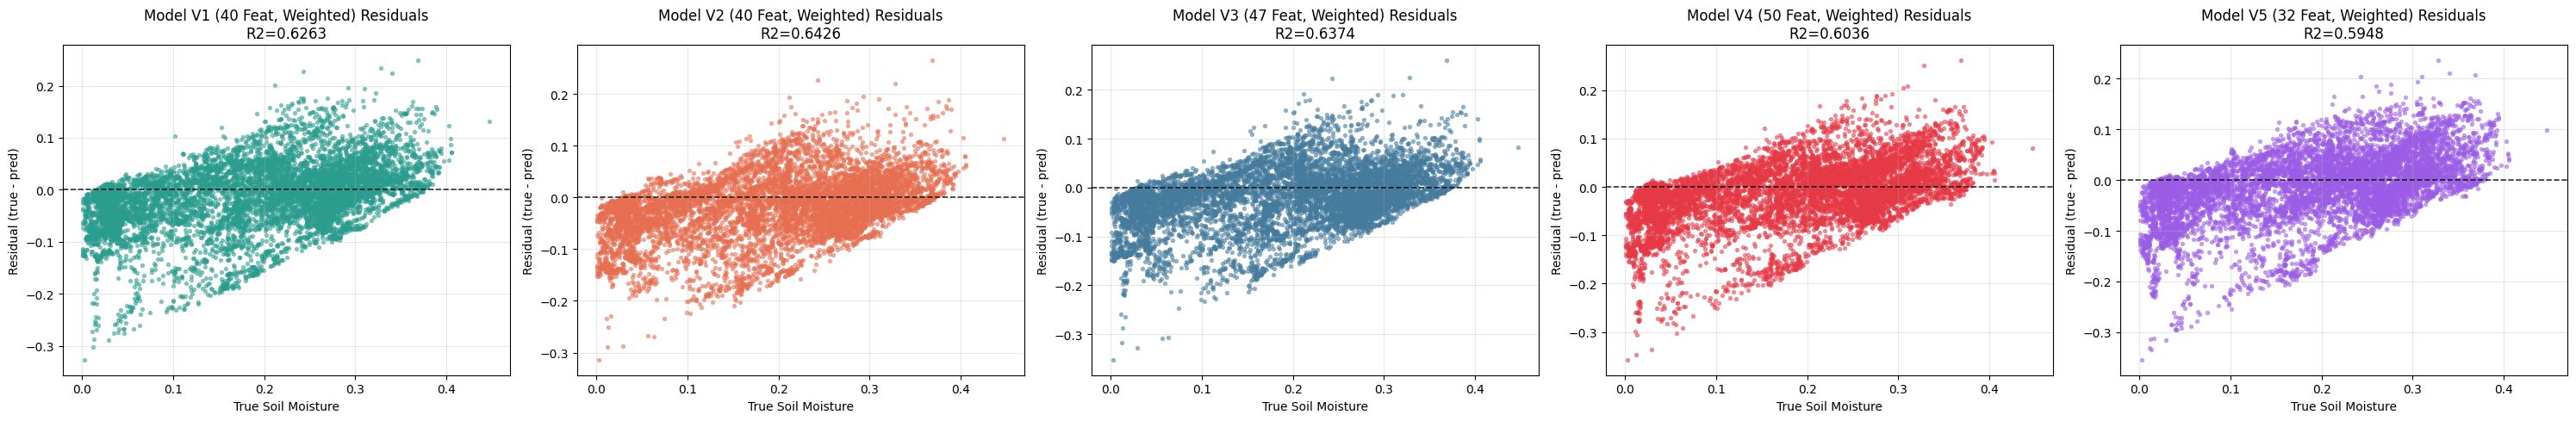

In [10]:
metrics_summary_data = {
    "Configuration": [
        "Model V1 (40 Features, No Weights)",
        "Model V1 (40 Features, Weighted)",
        "Model V2 (40 Features, No Weights)",
        "Model V2 (40 Features, Weighted)",
        "Model V3 (47 Features, No Weights)",
        "Model V3 (47 Features, Weighted)",
        "Model V4 (50 Features, No Weights)",
        "Model V4 (50 Features, Weighted)",
        "Model V5 (32 Features, No Weights)",
        "Model V5 (32 Features, Weighted)"
    ],
    "R2": [
        metrics_v1_no_w["R2"],
        metrics_v1_w["R2"],
        metrics_v2_no_w["R2"],
        metrics_v2_w["R2"],
        metrics_v3_no_w["R2"],
        metrics_v3_w["R2"],
        metrics_v4_no_w["R2"],
        metrics_v4_w["R2"],
        metrics_v5_no_w["R2"],
        metrics_v5_w["R2"]
    ],
    "RMSE": [
        metrics_v1_no_w["RMSE"],
        metrics_v1_w["RMSE"],
        metrics_v2_no_w["RMSE"],
        metrics_v2_w["RMSE"],
        metrics_v3_no_w["RMSE"],
        metrics_v3_w["RMSE"],
        metrics_v4_no_w["RMSE"],
        metrics_v4_w["RMSE"],
        metrics_v5_no_w["RMSE"],
        metrics_v5_w["RMSE"]
    ],
    "ubRMSE": [
        metrics_v1_no_w["ubRMSE"],
        metrics_v1_w["ubRMSE"],
        metrics_v2_no_w["ubRMSE"],
        metrics_v2_w["ubRMSE"],
        metrics_v3_no_w["ubRMSE"],
        metrics_v3_w["ubRMSE"],
        metrics_v4_no_w["ubRMSE"],
        metrics_v4_w["ubRMSE"],
        metrics_v5_no_w["ubRMSE"],
        metrics_v5_w["ubRMSE"]
    ],
    "Bias": [
        metrics_v1_no_w["Bias"],
        metrics_v1_w["Bias"],
        metrics_v2_no_w["Bias"],
        metrics_v2_w["Bias"],
        metrics_v3_no_w["Bias"],
        metrics_v3_w["Bias"],
        metrics_v4_no_w["Bias"],
        metrics_v4_w["Bias"],
        metrics_v5_no_w["Bias"],
        metrics_v5_w["Bias"]
    ],
    "MAE": [
        metrics_v1_no_w["MAE"],
        metrics_v1_w["MAE"],
        metrics_v2_no_w["MAE"],
        metrics_v2_w["MAE"],
        metrics_v3_no_w["MAE"],
        metrics_v3_w["MAE"],
        metrics_v4_no_w["MAE"],
        metrics_v4_w["MAE"],
        metrics_v5_no_w["MAE"],
        metrics_v5_w["MAE"]
    ],
    "Med|Err|": [
        metrics_v1_no_w["Med|Err|"],
        metrics_v1_w["Med|Err|"],
        metrics_v2_no_w["Med|Err|"],
        metrics_v2_w["Med|Err|"],
        metrics_v3_no_w["Med|Err|"],
        metrics_v3_w["Med|Err|"],
        metrics_v4_no_w["Med|Err|"],
        metrics_v4_w["Med|Err|"],
        metrics_v5_no_w["Med|Err|"],
        metrics_v5_w["Med|Err|"]
    ],
    "Pearson": [
        metrics_v1_no_w["Pearson"],
        metrics_v1_w["Pearson"],
        metrics_v2_no_w["Pearson"],
        metrics_v2_w["Pearson"],
        metrics_v3_no_w["Pearson"],
        metrics_v3_w["Pearson"],
        metrics_v4_no_w["Pearson"],
        metrics_v4_w["Pearson"],
        metrics_v5_no_w["Pearson"],
        metrics_v5_w["Pearson"]
    ]
}

summary_df = pd.DataFrame(metrics_summary_data)
print("\n===== COMPARATIVE PERFORMANCE SUMMARY =====")
print(summary_df.to_string(index=False, formatters={
    'R2': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'ubRMSE': '{:,.4f}'.format,
    'Bias': '{:+,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'Med|Err|': '{:,.4f}'.format,
    'Pearson': '{:,.4f}'.format
}))

out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-eval-1.2"
out_dir.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)

# Plot residuals comparison
res_v1_w = y_test - pred_v1_w
res_v2_w = y_test - pred_v2_w
res_v3_w = y_test - pred_v3_w
res_v4_w = y_test - pred_v4_w
res_v5_w = y_test - pred_v5_w

fig, axes = plt.subplots(1, 5, figsize=(30, 5))

axes[0].scatter(y_test, res_v1_w, s=8, alpha=0.5, color='#2a9d8f')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title(f"Model V1 (40 Feat, Weighted) Residuals\nR2={metrics_v1_w['R2']:.4f}")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, res_v2_w, s=8, alpha=0.5, color='#e76f51')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_ylabel("Residual (true - pred)")
axes[1].set_title(f"Model V2 (40 Feat, Weighted) Residuals\nR2={metrics_v2_w['R2']:.4f}")
axes[1].grid(alpha=0.3)

axes[2].scatter(y_test, res_v3_w, s=8, alpha=0.5, color='#457b9d')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[2].set_xlabel("True Soil Moisture")
axes[2].set_ylabel("Residual (true - pred)")
axes[2].set_title(f"Model V3 (47 Feat, Weighted) Residuals\nR2={metrics_v3_w['R2']:.4f}")
axes[2].grid(alpha=0.3)

axes[3].scatter(y_test, res_v4_w, s=8, alpha=0.5, color='#e63946')
axes[3].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[3].set_xlabel("True Soil Moisture")
axes[3].set_ylabel("Residual (true - pred)")
axes[3].set_title(f"Model V4 (50 Feat, Weighted) Residuals\nR2={metrics_v4_w['R2']:.4f}")
axes[3].grid(alpha=0.3)

axes[4].scatter(y_test, res_v5_w, s=8, alpha=0.5, color='#9b5de5')
axes[4].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[4].set_xlabel("True Soil Moisture")
axes[4].set_ylabel("Residual (true - pred)")
axes[4].set_title(f"Model V5 (32 Feat, Weighted) Residuals\nR2={metrics_v5_w['R2']:.4f}")
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / "residuals_comparison.png")
plt.show()


# Section 8: Year-by-Year Performance Evaluation & Residuals

We evaluate each of the 6 model configurations separately on each test year (2023, 2024, and 2025) to understand their performance consistency over time. To avoid redundant computation, we reuse the test set predictions computed in the previous sections by aligning them with their corresponding years.



===== YEARLY COMPARATIVE PERFORMANCE SUMMARY =====

--- Year: 2023 ---
                     Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
Model V1 (40 Features, No Weights) 0.5999 0.0681 0.0608 -0.0305 0.0502   0.0395  0.8274
  Model V1 (40 Features, Weighted) 0.6189 0.0664 0.0594 -0.0297 0.0500   0.0410  0.8359
Model V2 (40 Features, No Weights) 0.6337 0.0651 0.0579 -0.0298 0.0509   0.0422  0.8444
  Model V2 (40 Features, Weighted) 0.6382 0.0647 0.0583 -0.0281 0.0504   0.0413  0.8431
Model V3 (47 Features, No Weights) 0.6292 0.0655 0.0569 -0.0325 0.0509   0.0406  0.8503
  Model V3 (47 Features, Weighted) 0.6242 0.0660 0.0588 -0.0299 0.0514   0.0424  0.8411
Model V4 (50 Features, No Weights) 0.6040 0.0677 0.0624 -0.0263 0.0499   0.0383  0.8186
  Model V4 (50 Features, Weighted) 0.5938 0.0686 0.0634 -0.0261 0.0504   0.0390  0.8126
Model V5 (32 Features, No Weights) 0.5875 0.0691 0.0642 -0.0257 0.0517   0.0412  0.8082
  Model V5 (32 Features, Weighted) 0.5752 0.0701

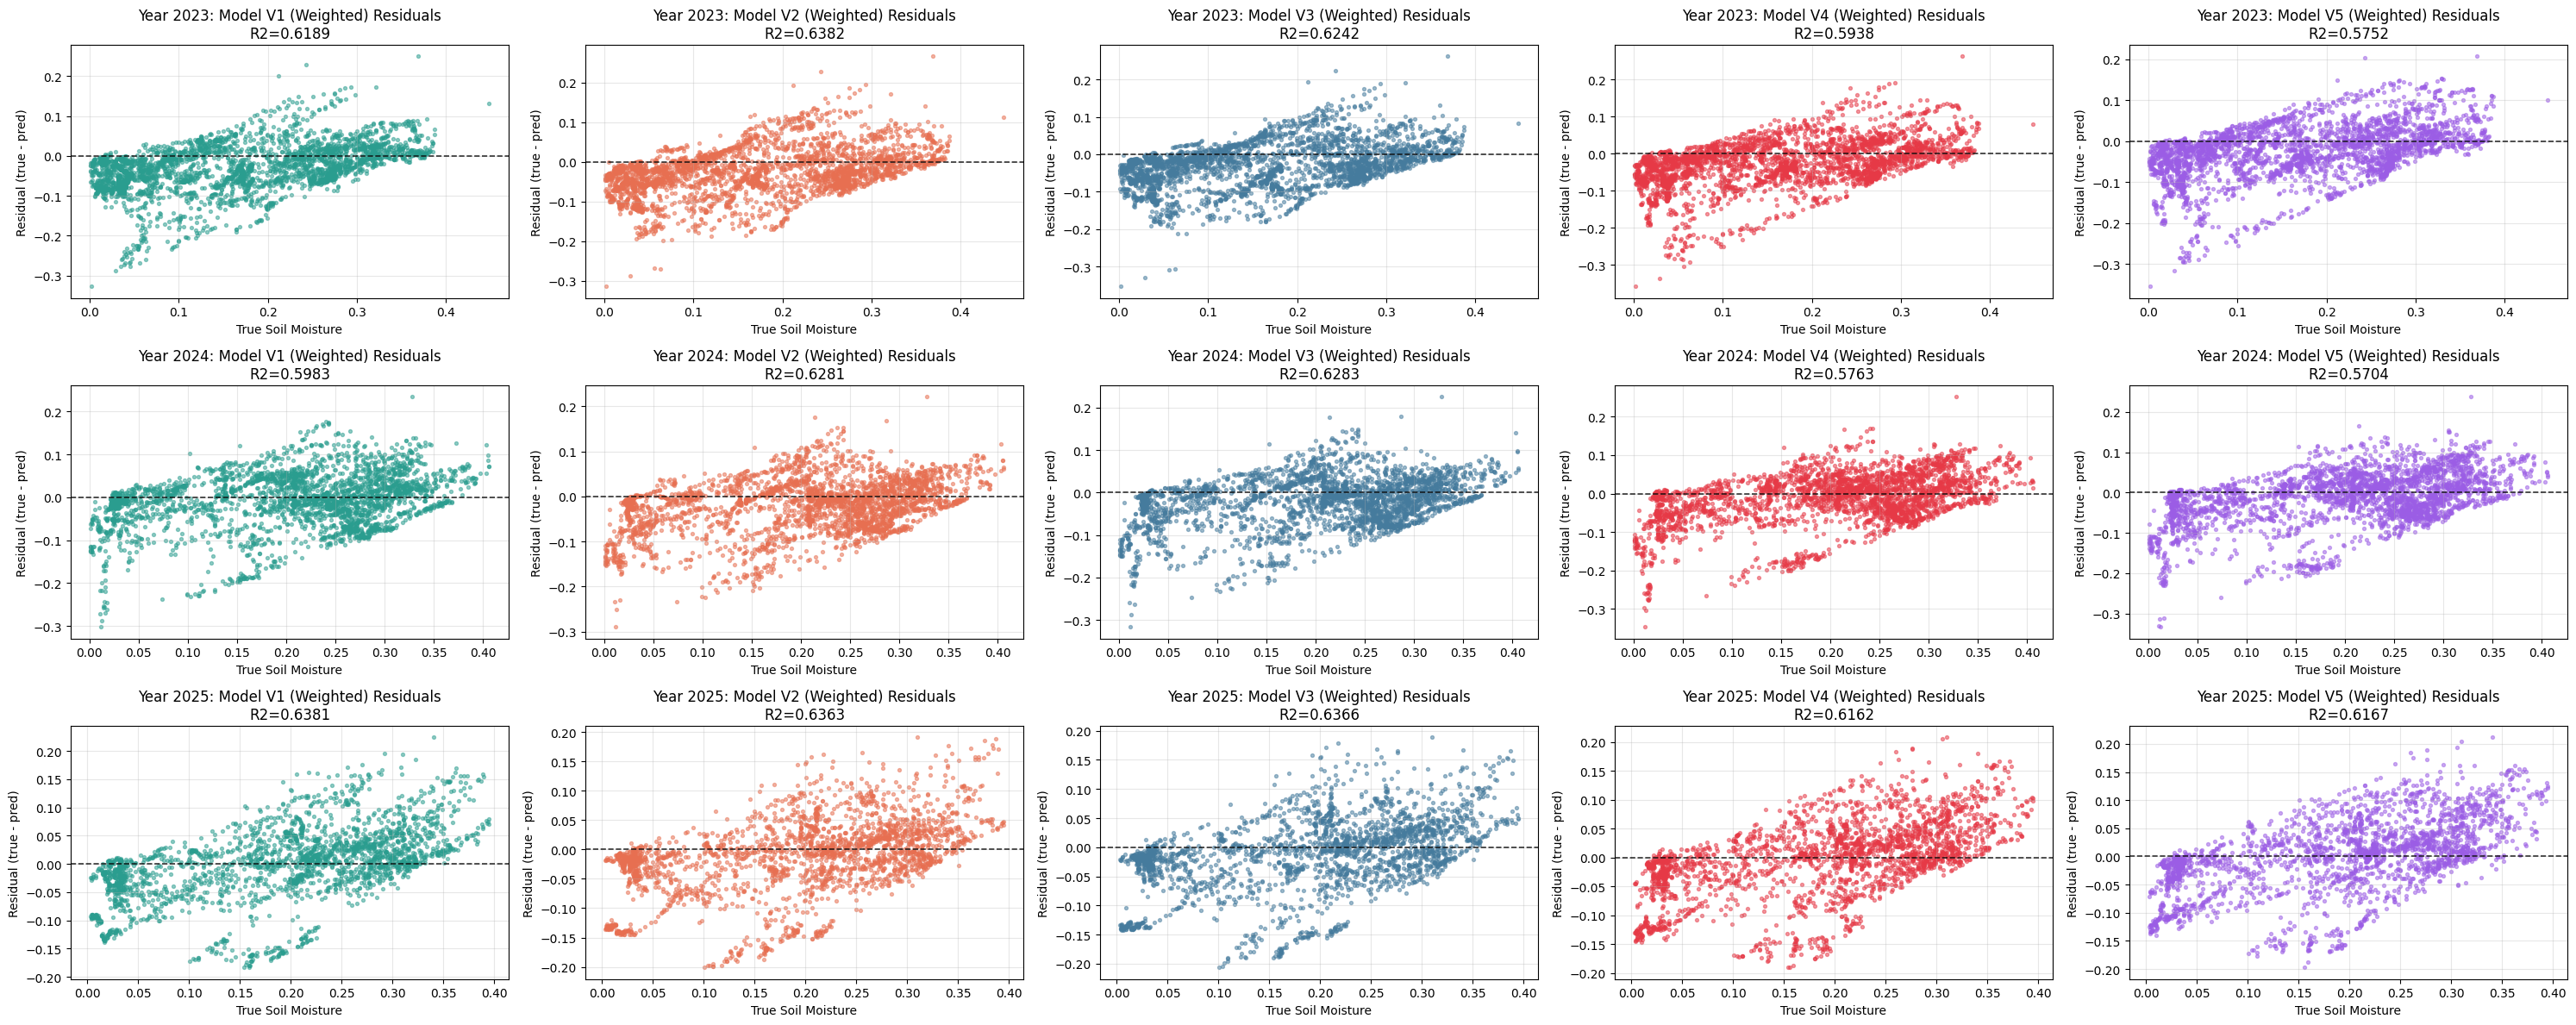

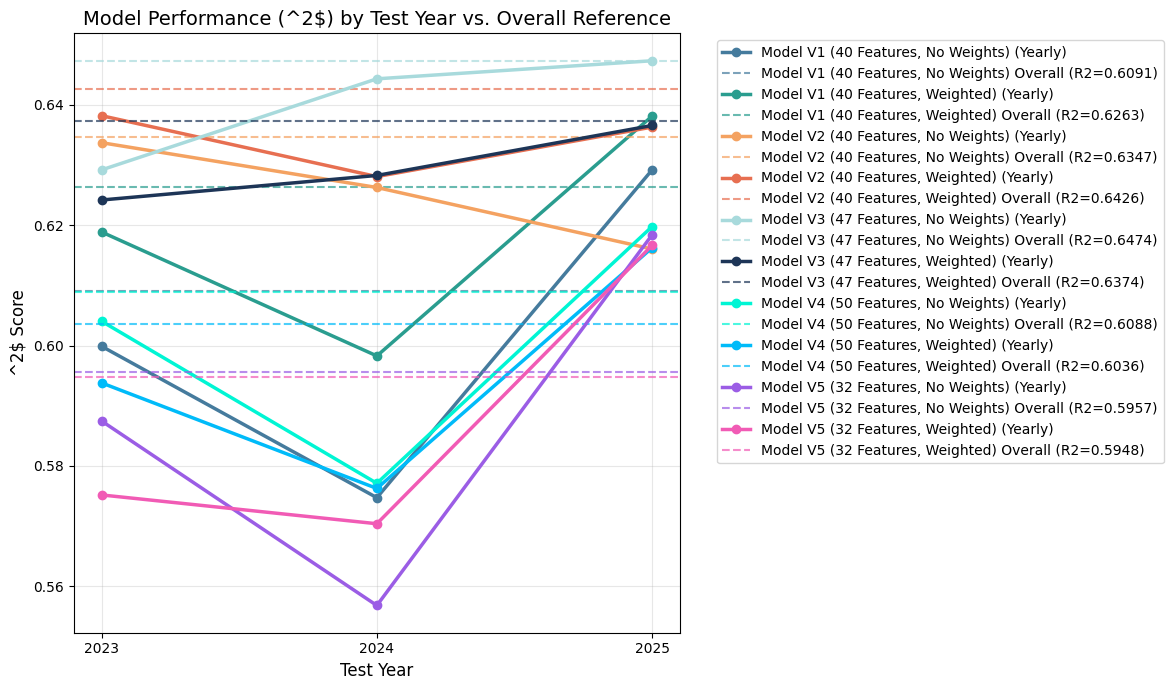

In [11]:
# Add predictions to test_df for slicing
test_df["pred_v1_no_w"] = pred_v1_no_w
test_df["pred_v1_w"] = pred_v1_w
test_df["pred_v2_no_w"] = pred_v2_no_w
test_df["pred_v2_w"] = pred_v2_w
test_df["pred_v3_no_w"] = pred_v3_no_w
test_df["pred_v3_w"] = pred_v3_w
test_df["pred_v4_no_w"] = pred_v4_no_w
test_df["pred_v4_w"] = pred_v4_w
test_df["pred_v5_no_w"] = pred_v5_no_w
test_df["pred_v5_w"] = pred_v5_w

test_years = sorted(test_df["year"].unique())
yearly_metrics_list = []

for yr in test_years:
    df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
    y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
    
    # 1. Model V1 No Weights
    m_v1_now = compute_metrics(y_test_yr, df_yr["pred_v1_no_w"])
    m_v1_now["Year"] = int(yr)
    m_v1_now["Configuration"] = "Model V1 (40 Features, No Weights)"
    
    # 2. Model V1 Weighted
    m_v1_w = compute_metrics(y_test_yr, df_yr["pred_v1_w"])
    m_v1_w["Year"] = int(yr)
    m_v1_w["Configuration"] = "Model V1 (40 Features, Weighted)"
    
    # 3. Model V2 No Weights
    m_v2_now = compute_metrics(y_test_yr, df_yr["pred_v2_no_w"])
    m_v2_now["Year"] = int(yr)
    m_v2_now["Configuration"] = "Model V2 (40 Features, No Weights)"
    
    # 4. Model V2 Weighted
    m_v2_w = compute_metrics(y_test_yr, df_yr["pred_v2_w"])
    m_v2_w["Year"] = int(yr)
    m_v2_w["Configuration"] = "Model V2 (40 Features, Weighted)"
    
    # 5. Model V3 No Weights
    m_v3_now = compute_metrics(y_test_yr, df_yr["pred_v3_no_w"])
    m_v3_now["Year"] = int(yr)
    m_v3_now["Configuration"] = "Model V3 (47 Features, No Weights)"
    
    # 6. Model V3 Weighted
    m_v3_w = compute_metrics(y_test_yr, df_yr["pred_v3_w"])
    m_v3_w["Year"] = int(yr)
    m_v3_w["Configuration"] = "Model V3 (47 Features, Weighted)"

    # 7. Model V4 No Weights
    m_v4_now = compute_metrics(y_test_yr, df_yr["pred_v4_no_w"])
    m_v4_now["Year"] = int(yr)
    m_v4_now["Configuration"] = "Model V4 (50 Features, No Weights)"
    
    # 8. Model V4 Weighted
    m_v4_w = compute_metrics(y_test_yr, df_yr["pred_v4_w"])
    m_v4_w["Year"] = int(yr)
    m_v4_w["Configuration"] = "Model V4 (50 Features, Weighted)"
    
    # 9. Model V5 No Weights
    m_v5_now = compute_metrics(y_test_yr, df_yr["pred_v5_no_w"])
    m_v5_now["Year"] = int(yr)
    m_v5_now["Configuration"] = "Model V5 (32 Features, No Weights)"
    
    # 10. Model V5 Weighted
    m_v5_w = compute_metrics(y_test_yr, df_yr["pred_v5_w"])
    m_v5_w["Year"] = int(yr)
    m_v5_w["Configuration"] = "Model V5 (32 Features, Weighted)"
    
    yearly_metrics_list.extend([
        m_v1_now, m_v1_w, m_v2_now, m_v2_w, m_v3_now, m_v3_w, m_v4_now, m_v4_w, m_v5_now, m_v5_w
    ])

yearly_summary_df = pd.DataFrame(yearly_metrics_list)
# Reorder columns
cols = ["Year", "Configuration", "R2", "RMSE", "ubRMSE", "Bias", "MAE", "Med|Err|", "Pearson"]
yearly_summary_df = yearly_summary_df[cols]

print("\n===== YEARLY COMPARATIVE PERFORMANCE SUMMARY =====")
for yr in test_years:
    print(f"\n--- Year: {int(yr)} ---")
    df_yr_m = yearly_summary_df[yearly_summary_df["Year"] == yr].drop(columns=["Year"])
    print(df_yr_m.to_string(index=False, formatters={
        'R2': '{:,.4f}'.format,
        'RMSE': '{:,.4f}'.format,
        'ubRMSE': '{:,.4f}'.format,
        'Bias': '{:+,.4f}'.format,
        'MAE': '{:,.4f}'.format,
        'Med|Err|': '{:,.4f}'.format,
        'Pearson': '{:,.4f}'.format
    }))

out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.2-eval-1.2"
yearly_summary_df.to_csv(out_dir / "metrics_by_year.csv", index=False)

# Plot residuals by year for the weighted models (V1, V2, V3, V4, and V5)
fig, axes = plt.subplots(len(test_years), 5, figsize=(30, 4 * len(test_years)))

for i, yr in enumerate(test_years):
    df_yr = test_df[test_df["year"] == yr].reset_index(drop=True)
    y_test_yr = np.asarray(df_yr[TARGET_COL]).ravel()
    
    res_v1_w = y_test_yr - df_yr["pred_v1_w"]
    res_v2_w = y_test_yr - df_yr["pred_v2_w"]
    res_v3_w = y_test_yr - df_yr["pred_v3_w"]
    res_v4_w = y_test_yr - df_yr["pred_v4_w"]
    res_v5_w = y_test_yr - df_yr["pred_v5_w"]
    
    r2_v1 = r2_score(y_test_yr, df_yr["pred_v1_w"])
    r2_v2 = r2_score(y_test_yr, df_yr["pred_v2_w"])
    r2_v3 = r2_score(y_test_yr, df_yr["pred_v3_w"])
    r2_v4 = r2_score(y_test_yr, df_yr["pred_v4_w"])
    r2_v5 = r2_score(y_test_yr, df_yr["pred_v5_w"])
    
    # Model V1 plot
    axes[i, 0].scatter(y_test_yr, res_v1_w, s=8, alpha=0.5, color='#2a9d8f')
    axes[i, 0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i, 0].set_xlabel("True Soil Moisture")
    axes[i, 0].set_ylabel("Residual (true - pred)")
    axes[i, 0].set_title(f"Year {int(yr)}: Model V1 (Weighted) Residuals\nR2={r2_v1:.4f}")
    axes[i, 0].grid(alpha=0.3)
    
    # Model V2 plot
    axes[i, 1].scatter(y_test_yr, res_v2_w, s=8, alpha=0.5, color='#e76f51')
    axes[i, 1].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i, 1].set_xlabel("True Soil Moisture")
    axes[i, 1].set_ylabel("Residual (true - pred)")
    axes[i, 1].set_title(f"Year {int(yr)}: Model V2 (Weighted) Residuals\nR2={r2_v2:.4f}")
    axes[i, 1].grid(alpha=0.3)

    # Model V3 plot
    axes[i, 2].scatter(y_test_yr, res_v3_w, s=8, alpha=0.5, color='#457b9d')
    axes[i, 2].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i, 2].set_xlabel("True Soil Moisture")
    axes[i, 2].set_ylabel("Residual (true - pred)")
    axes[i, 2].set_title(f"Year {int(yr)}: Model V3 (Weighted) Residuals\nR2={r2_v3:.4f}")
    axes[i, 2].grid(alpha=0.3)

    # Model V4 plot
    axes[i, 3].scatter(y_test_yr, res_v4_w, s=8, alpha=0.5, color='#e63946')
    axes[i, 3].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i, 3].set_xlabel("True Soil Moisture")
    axes[i, 3].set_ylabel("Residual (true - pred)")
    axes[i, 3].set_title(f"Year {int(yr)}: Model V4 (Weighted) Residuals\nR2={r2_v4:.4f}")
    axes[i, 3].grid(alpha=0.3)

    # Model V5 plot
    axes[i, 4].scatter(y_test_yr, res_v5_w, s=8, alpha=0.5, color='#9b5de5')
    axes[i, 4].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i, 4].set_xlabel("True Soil Moisture")
    axes[i, 4].set_ylabel("Residual (true - pred)")
    axes[i, 4].set_title(f"Year {int(yr)}: Model V5 (Weighted) Residuals\nR2={r2_v5:.4f}")
    axes[i, 4].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / "residuals_by_year.png")
plt.show()

# Plot R2 comparison by year including overall R2 for reference
overall_r2 = {
    "Model V1 (40 Features, No Weights)": metrics_v1_no_w["R2"],
    "Model V1 (40 Features, Weighted)": metrics_v1_w["R2"],
    "Model V2 (40 Features, No Weights)": metrics_v2_no_w["R2"],
    "Model V2 (40 Features, Weighted)": metrics_v2_w["R2"],
    "Model V3 (47 Features, No Weights)": metrics_v3_no_w["R2"],
    "Model V3 (47 Features, Weighted)": metrics_v3_w["R2"],
    "Model V4 (50 Features, No Weights)": metrics_v4_no_w["R2"],
    "Model V4 (50 Features, Weighted)": metrics_v4_w["R2"],
    "Model V5 (32 Features, No Weights)": metrics_v5_no_w["R2"],
    "Model V5 (32 Features, Weighted)": metrics_v5_w["R2"]
}

colors = {
    "Model V1 (40 Features, No Weights)": "#457b9d",
    "Model V1 (40 Features, Weighted)": "#2a9d8f",
    "Model V2 (40 Features, No Weights)": "#f4a261",
    "Model V2 (40 Features, Weighted)": "#e76f51",
    "Model V3 (47 Features, No Weights)": "#a8dadc",
    "Model V3 (47 Features, Weighted)": "#1d3557",
    "Model V4 (50 Features, No Weights)": "#00f5d4",
    "Model V4 (50 Features, Weighted)": "#00bbf9",
    "Model V5 (32 Features, No Weights)": "#9b5de5",
    "Model V5 (32 Features, Weighted)": "#f15bb5"
}

plt.figure(figsize=(12, 7))

for config in overall_r2.keys():
    df_config = yearly_summary_df[yearly_summary_df["Configuration"] == config]
    years_plot = df_config["Year"].values
    r2_plot = df_config["R2"].values
    
    # Plot yearly trend
    plt.plot(years_plot, r2_plot, marker='o', linewidth=2.5, color=colors[config], label=f"{config} (Yearly)")
    
    # Plot overall R2 reference line
    plt.axhline(overall_r2[config], linestyle='--', color=colors[config], alpha=0.7, 
                label=f"{config} Overall (R2={overall_r2[config]:.4f})")

plt.xticks(test_years, [str(int(y)) for y in test_years])
plt.xlabel("Test Year", fontsize=12)
plt.ylabel("^2$ Score", fontsize=12)
plt.title("Model Performance (^2$) by Test Year vs. Overall Reference", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / "r2_by_year.png", dpi=300)
plt.show()
